In [12]:
import requests
import pandas as pd

def get_bitc_klines(interval,limit):
    url = 'https://api.binance.com/api/v3/klines'
    params={
    "symbol":"BTCUSDT",
    "interval":interval,
    "limit":limit
    }

    response=requests.get(url,params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame(data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ])
    df['open_time']=pd.to_datetime(df['open_time'],unit='ms')
    df['close']=df['close'].astype(float)
    df['open']=df['open'].astype(float)
    df['btc_zmiana'] = df['open']-df['close']
   

    return df[['open_time','btc_zmiana']]

In [44]:
import requests
import pandas as pd
import pandas_ta as ta 
import numpy as np

def get_klines(symbol,interval,limit):
    url = 'https://api.binance.com/api/v3/klines'
    params={
    "symbol":symbol,
    "interval":interval,
    "limit":limit
    }

    response = requests.get(url,params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame(data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ])
    df['open_time']=pd.to_datetime(df['open_time'],unit='ms')

    #cechy bezpośrednie
    df['open']=df['open'].astype(float).round(1)
    df['high']=df['high'].astype(float).round(1)
    df['low']=df['low'].astype(float).round(1)
    df['close']=df['close'].astype(float).round(1)

    #cechy pochodne
    df['zmiana']=df['open']-df['close'].round(1)
    df['zakres']=df['high']-df['low'].round(1)
    df['zwrot']=df['close'].pct_change().round(4)
    df['zwrot_log']=(df['close'] /df['close'].shift(1)).apply(lambda x:np.log(x)).round(4)
    df['zmiana_rel']=(df['close']-df['open'])/df['open']

    df['volume']=df['volume'].astype(float)
    df['vol_zmiana']=df['volume'].pct_change()

    #wskaźniki techniczne
    df['rsi']=ta.rsi(df['close'],length=14)
    df['ema10']=ta.ema(df['close'], length=10).round(1)
    df['sma10']=ta.sma(df['close'],length=10)
    df['macd'] = ta.macd(df['close'])['MACD_12_26_9']

    bb = ta.bbands(df['close'], length=20)
    df['bb_lower'] = bb['BBL_20_2.0']
    df['bb_middle'] = bb['BBM_20_2.0']
    df['bb_upper'] = bb['BBU_20_2.0']
    df['bb_width'] = bb['BBB_20_2.0']


    df['rsi_lag1'] = df['rsi'].shift(1)
    df['rsi_delta'] = df['rsi'] - df['rsi'].shift(1)

    df['macd_lag1'] = df['macd'].shift(1)
    df['ema_delta'] = df['ema10'] - df['ema10'].shift(1)


    df['hour']=df['open_time'].dt.hour
    df['day']=df['open_time'].dt.dayofweek
    df['is_weekend']=df['day'].isin([5,6]).astype(int)

    
    return df[['rsi_lag1','rsi_delta','macd_lag1','ema_delta',"open_time","hour","day","is_weekend","open","high","low","close","volume",'zmiana','zakres','zwrot','zwrot_log','zmiana_rel','vol_zmiana','rsi','ema10','sma10','macd','bb_upper','bb_middle','bb_lower','bb_width']]

symbol="SOLUSDT"
interval='2h'
limit=1000


df= get_klines(symbol,interval,limit)
dfbtc=get_bitc_klines(interval,limit)
dfbtc

,open_time,btc_zmiana
0,2025-05-08 02:00:00,-1336.57
1,2025-05-08 04:00:00,412.18
2,2025-05-08 06:00:00,-511.74
3,2025-05-08 08:00:00,-538.63
4,2025-05-08 10:00:00,381.83
...,...,...
995,2025-07-30 00:00:00,88.70
996,2025-07-30 02:00:00,-299.82
997,2025-07-30 04:00:00,169.60
998,2025-07-30 06:00:00,-130.75


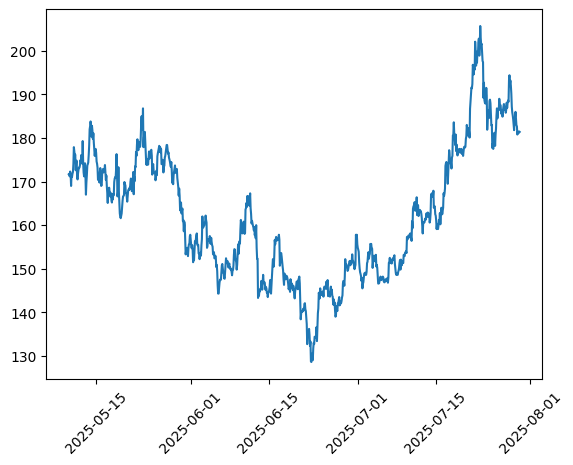

In [40]:
import matplotlib.pyplot as plt

plt.plot(df["open_time"],df["open"])
plt.xticks(rotation=45)
plt.show()


In [46]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import plot_importance
from sklearn.metrics import ConfusionMatrixDisplay

df = df.copy()

df['targer_simple']=df['close'].shift(-1)>df['close'].astype(int)

df['zmiana_ceny'] = df['close'].shift(-1)-df['close']
prog=df['close']*0.0027

df['target'] = df.apply(lambda row: 
    2 if row['zmiana_ceny']>prog.loc[row.name]
    else 0 if row['zmiana_ceny'] < -prog.loc[row.name]
    else 1,
    axis=1
)

df = df.dropna()

dfbtc=dfbtc.dropna()

df_new= pd.merge(df, dfbtc, on='open_time', how='inner')

features = [
    "volume",
    "zmiana",
    "zakres",
    "rsi",
    "macd",
    "ema10",      
    "bb_width",   
    "is_weekend",
    "hour",
    "day",
    "btc_zmiana",
    'rsi_lag1','rsi_delta','macd_lag1','ema_delta'
    
]
X = df_new[features]
y = df_new['target_simple']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parametry do przeszukania
param_grid = {
    'n_estimators': [50],         # liczba drzew
    'max_depth': [15],               # maksymalna głębokość drzewa
    'learning_rate': [0.1],     # tempo uczenia
    'subsample': [1.0],                # procent próbek do każdego drzewa
    'colsample_bytree': [1.0],         # procent cech do każdego drzewa
    'gamma': [0.5],                 # minimalna redukcja straty do podziału
    'min_child_weight': [1],          # minimalna suma wag w liściu
    'reg_alpha': [0.5],               # L1 regularization
    'reg_lambda': [0.1]              # L2 regularization
}

# GridSearchCV
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=2,                # liczba foldów w cross-validation
    scoring='accuracy',  # metryka do optymalizacji
    n_jobs=-1,           # użyj wszystkich rdzeni CPU
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik cross-val:", grid_search.best_score_)


# Test na zbiorze testowym
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy na testowym:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


plot_importance(best_model, importance_type='gain', max_num_features=10)
plt.title("Najważniejsze cechy (gain)")
plt.tight_layout()
plt.show()


ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

KeyError: 'target_simple'

In [39]:
print(y.value_counts(normalize=True))


target
2    0.389517
0    0.363823
1    0.246660
Name: proportion, dtype: float64
